In [2]:
import pandas as pd


In [3]:
### Data Ingestion & Validation

## Load Data

df=pd.read_csv("C:\\Users\\lenovo\\Downloads\\Afficionado Coffee Roasters.csv")

In [4]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
### Validate Product Identifiers & Prices

df['product_id'].nunique()   # Unique products
df['unit_price'].describe()  # check price range

80

In [6]:
df['unit_price'].describe()  # check price range

count    149116.000000
mean          3.382219
std           2.658723
min           0.800000
25%           2.500000
50%           3.000000
75%           3.750000
max          45.000000
Name: unit_price, dtype: float64

In [ ]:
# Ensure quantities are positive
df[df['transaction_qty']<=0]


In [ ]:
## 2) Revenue computation
### Computing revenue 
df['revenue']=df['transaction_qty']*df['unit_price']

In [27]:
df['revenue']

0         6.00
1         6.20
2         9.00
3         2.00
4         6.20
          ... 
149111    5.00
149112    6.00
149113    3.00
149114    3.75
149115    1.60
Name: revenue, Length: 149116, dtype: float64

In [28]:
df.head(5)

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [29]:
# Aggregate revenue by product,product type,product category

## By product
rev_product=df.groupby("product_detail")['revenue'].sum()

rev_product

product_detail
Almond Croissant                 7168.13
Brazilian - Organic              3852.00
Brazilian Lg                    15109.50
Brazilian Rg                    13155.00
Brazilian Sm                     9482.00
                                  ...   
Sustainably Grown Organic Lg    21151.75
Sustainably Grown Organic Rg    16233.75
Traditional Blend Chai           1369.35
Traditional Blend Chai Lg       12522.00
Traditional Blend Chai Rg       11280.00
Name: revenue, Length: 80, dtype: float64

In [30]:
## By Product_type

rev_product_type=df.groupby("product_type")['revenue'].sum()

rev_product_type

product_type
Barista Espresso         91406.20
Biscotti                 19793.53
Black tea                 2711.85
Brewed Black tea         47932.00
Brewed Chai tea          77081.95
Brewed Green tea         23852.50
Brewed herbal tea        47539.50
Chai tea                  4301.25
Clothing                  6163.00
Drinking Chocolate        2728.04
Drip coffee              31984.00
Espresso Beans            5560.25
Gourmet Beans             6798.00
Gourmet brewed coffee    70034.60
Green beans               1340.00
Green tea                 1470.75
Herbal tea                2729.75
Hot chocolate            72416.00
House blend Beans         3294.00
Housewares                7444.00
Organic Beans             8509.50
Organic Chocolate         1679.60
Organic brewed coffee    37746.50
Pastry                   25655.99
Premium Beans            14583.50
Premium brewed coffee    38781.15
Regular syrup             6084.80
Scone                    36866.12
Sugar free syrup          2324.00
N

In [31]:
# By Category


rev_pro_category=df.groupby("product_category")['revenue'].sum()

rev_pro_category

product_category
Bakery                 82315.64
Branded                13607.00
Coffee                269952.45
Coffee beans           40085.25
Drinking Chocolate     72416.00
Flavours                8408.80
Loose Tea              11213.60
Packaged Chocolate      4407.64
Tea                   196405.95
Name: revenue, dtype: float64

In [32]:
## Product Popularity Analysis

## Total units sold product (volume)

unit_pro=df.groupby('product_detail')['transaction_qty'].sum()

In [33]:
unit_pro

product_detail
Almond Croissant                1911
Brazilian - Organic              214
Brazilian Lg                    4317
Brazilian Rg                    4385
Brazilian Sm                    4310
                                ... 
Sustainably Grown Organic Lg    4453
Sustainably Grown Organic Rg    4329
Traditional Blend Chai           153
Traditional Blend Chai Lg       4174
Traditional Blend Chai Rg       4512
Name: transaction_qty, Length: 80, dtype: int64

In [34]:
# Ranking products by sales volume

rank_sort=unit_pro.sort_values(ascending=False)

rank_sort

product_detail
Earl Grey Rg                    4708
Dark chocolate Lg               4668
Morning Sunrise Chai Rg         4643
Latte                           4602
Peppermint Rg                   4564
                                ... 
Jamacian Coffee River            146
Earl Grey                        142
Guatemalan Sustainably Grown     134
Spicy Eye Opener Chai            122
Dark chocolate                   118
Name: transaction_qty, Length: 80, dtype: int64

In [35]:
# Top Performers

rank_sort.head(10)

product_detail
Earl Grey Rg                   4708
Dark chocolate Lg              4668
Morning Sunrise Chai Rg        4643
Latte                          4602
Peppermint Rg                  4564
Columbian Medium Roast Rg      4547
Traditional Blend Chai Rg      4512
Latte Rg                       4497
Our Old Time Diner Blend Sm    4484
Serenity Green Tea Rg          4477
Name: transaction_qty, dtype: int64

In [36]:
# Bottom Performers

rank_sort.tail(10)

product_detail
Traditional Blend Chai          153
Lemon Grass                     152
Primo Espresso Roast            150
Columbian Medium Roast          148
Chili Mayan                     148
Jamacian Coffee River           146
Earl Grey                       142
Guatemalan Sustainably Grown    134
Spicy Eye Opener Chai           122
Dark chocolate                  118
Name: transaction_qty, dtype: int64

In [37]:
### Revenue contribution  Analysis

## revenue contribution by Product
rev_pro=df.groupby('product_detail')['revenue'].sum()
rev_pro

product_detail
Almond Croissant                 7168.13
Brazilian - Organic              3852.00
Brazilian Lg                    15109.50
Brazilian Rg                    13155.00
Brazilian Sm                     9482.00
                                  ...   
Sustainably Grown Organic Lg    21151.75
Sustainably Grown Organic Rg    16233.75
Traditional Blend Chai           1369.35
Traditional Blend Chai Lg       12522.00
Traditional Blend Chai Rg       11280.00
Name: revenue, Length: 80, dtype: float64

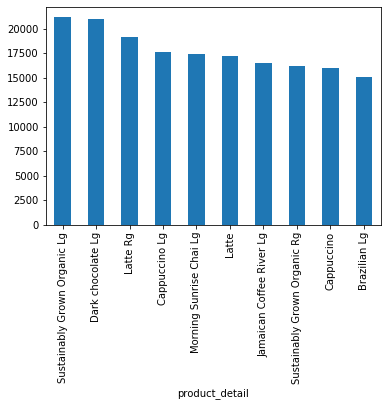

In [39]:
import matplotlib.pyplot as plt
rev_pro.sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()


In [40]:
### Revenue share(%)

rev_share=(rev_pro/rev_pro.sum())*100
rev_share

product_detail
Almond Croissant                1.025759
Brazilian - Organic             0.551221
Brazilian Lg                    2.162168
Brazilian Rg                    1.882480
Brazilian Sm                    1.356874
                                  ...   
Sustainably Grown Organic Lg    3.026814
Sustainably Grown Organic Rg    2.323049
Traditional Blend Chai          0.195954
Traditional Blend Chai Lg       1.791897
Traditional Blend Chai Rg       1.614167
Name: revenue, Length: 80, dtype: float64

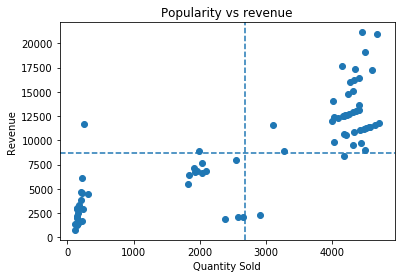

In [41]:
## Comparision b/w volume rank and revenue rank

import matplotlib.pyplot as plt

x=unit_pro
y=rev_pro

plt.scatter(x,y)
plt.axvline(x.mean(), linestyle='--')
plt.axhline(y.mean(), linestyle='--')

plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")

plt.title("Popularity vs revenue")
plt.show()

In [42]:
## Category & product type Performance

### Revenue share by category(coffee, tea,chocolate)


cat_share=(rev_pro_category/ rev_pro_category.sum())*100

cat_share

product_category
Bakery                11.779363
Branded                1.947161
Coffee                38.630178
Coffee beans           5.736197
Drinking Chocolate    10.362725
Flavours               1.203299
Loose Tea              1.604665
Packaged Chocolate     0.630733
Tea                   28.105679
Name: revenue, dtype: float64

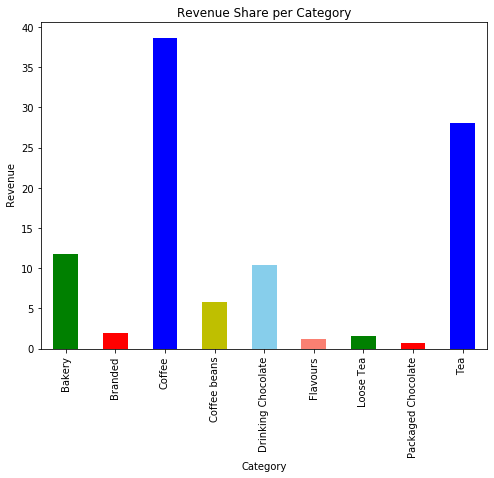

In [43]:
#Revenue shar per category visualization with Chart

cat_share.plot(kind='bar',figsize=(8,6), color=['g','r','b','y','skyblue','salmon'])
plt.ylabel(" Revenue")
plt.title("Revenue Share per Category")
plt.xlabel("Category")
plt.show()

In [44]:
# Product type contribution within each category

df.groupby(["product_category","product_type"])["revenue"].sum()

product_category    product_type         
Bakery              Biscotti                 19793.53
                    Pastry                   25655.99
                    Scone                    36866.12
Branded             Clothing                  6163.00
                    Housewares                7444.00
Coffee              Barista Espresso         91406.20
                    Drip coffee              31984.00
                    Gourmet brewed coffee    70034.60
                    Organic brewed coffee    37746.50
                    Premium brewed coffee    38781.15
Coffee beans        Espresso Beans            5560.25
                    Gourmet Beans             6798.00
                    Green beans               1340.00
                    House blend Beans         3294.00
                    Organic Beans             8509.50
                    Premium Beans            14583.50
Drinking Chocolate  Hot chocolate            72416.00
Flavours            Regular syrup       

In [45]:
# dependence analysis on core categories

cat_share.sort_values(ascending=False)

product_category
Coffee                38.630178
Tea                   28.105679
Bakery                11.779363
Drinking Chocolate    10.362725
Coffee beans           5.736197
Branded                1.947161
Loose Tea              1.604665
Flavours               1.203299
Packaged Chocolate     0.630733
Name: revenue, dtype: float64

In [ ]:
###  REVENUE CONCENTRATION & MENU BALANCE

In [46]:
# Pareto 80/20 analysis
rev_sorted=rev_pro.sort_values(ascending=False)

# Cumulative revenue percentage

cum_perc=(rev_sorted.cumsum()/rev_sorted.sum())*100        

# MENU DIVERSIFICATION RISK
cum_perc

product_detail
Sustainably Grown Organic Lg      3.026814
Dark chocolate Lg                 6.032771
Latte Rg                          8.767733
Cappuccino Lg                    11.292266
Morning Sunrise Chai Lg          13.779916
                                   ...    
Lemon Grass                      99.327144
Guatemalan Sustainably Grown     99.518898
Spicy Eye Opener Chai            99.710065
Earl Grey                        99.891931
Dark chocolate                  100.000000
Name: revenue, Length: 80, dtype: float64

In [47]:
cum_perc[cum_perc<=80]

product_detail
Sustainably Grown Organic Lg     3.026814
Dark chocolate Lg                6.032771
Latte Rg                         8.767733
Cappuccino Lg                   11.292266
Morning Sunrise Chai Lg         13.779916
Latte                           16.249463
Jamaican Coffee River Lg        18.607929
Sustainably Grown Organic Rg    20.930977
Cappuccino                      23.220219
Brazilian Lg                    25.382387
Ethiopia Lg                     27.499479
Dark chocolate Rg               29.506384
Spicy Eye Opener Chai Lg        31.460042
Ethiopia Rg                     33.345956
Brazilian Rg                    35.228435
Peppermint Lg                   37.095890
English Breakfast Lg            38.945742
Earl Grey Lg                    40.768120
Serenity Green Tea Lg           42.579765
Columbian Medium Roast Lg       44.380678
Traditional Blend Chai Lg       46.172575
Espresso shot                   47.960609
Jamaican Coffee River Rg        49.743033
Lemon Grass Lg     

In [48]:
# Products contributing upto 80% revenue     it took 42 products to reach 80%

len(cum_perc[cum_perc[cum_perc<=80]])

42

In [49]:
products_80=cum_perc[cum_perc<=80]
products_80

product_detail
Sustainably Grown Organic Lg     3.026814
Dark chocolate Lg                6.032771
Latte Rg                         8.767733
Cappuccino Lg                   11.292266
Morning Sunrise Chai Lg         13.779916
Latte                           16.249463
Jamaican Coffee River Lg        18.607929
Sustainably Grown Organic Rg    20.930977
Cappuccino                      23.220219
Brazilian Lg                    25.382387
Ethiopia Lg                     27.499479
Dark chocolate Rg               29.506384
Spicy Eye Opener Chai Lg        31.460042
Ethiopia Rg                     33.345956
Brazilian Rg                    35.228435
Peppermint Lg                   37.095890
English Breakfast Lg            38.945742
Earl Grey Lg                    40.768120
Serenity Green Tea Lg           42.579765
Columbian Medium Roast Lg       44.380678
Traditional Blend Chai Lg       46.172575
Espresso shot                   47.960609
Jamaican Coffee River Rg        49.743033
Lemon Grass Lg     

In [50]:
len(products_80)

42

In [51]:
# Percentage of products required to reach 80% revenue

(len(products_80) / len(cum_perc))*100

52.5

In [ ]:
# it showed that 42 out of 80 products(52.5%) were required to generate 80% of total revenue

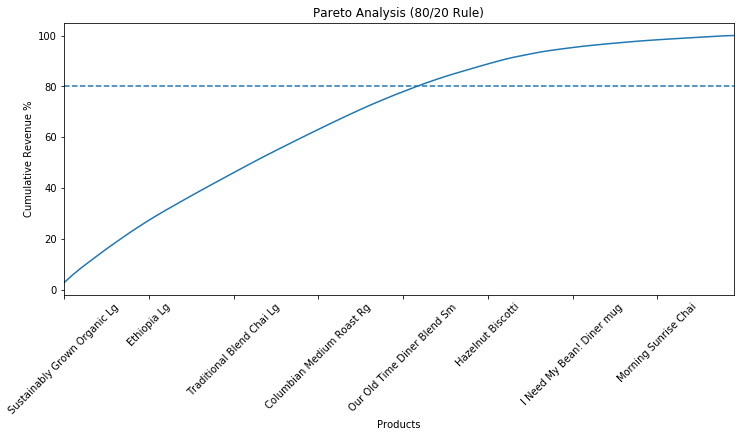

In [52]:
import matplotlib.pyplot as plt

cum_perc.plot(figsize=(12,5))

plt.axhline(y=80, linestyle='--')
plt.ylabel("Cumulative Revenue %")
plt.xlabel("Products")
plt.xticks(rotation=45)
plt.title("Pareto Analysis (80/20 Rule)")
plt.show()

In [ ]:
# EVALUATION OF MENU DIVERSIFICATION RISK 

Pareto analysis showed that approximately 52.5% of products contribute to 80% of total revenue, indicating that revenue is
    distributed across a relatively broad product portfolio rather than being concentrated among a few products. This suggests 
    low to moderate menu diversification risk.

In [53]:
# identifying revenue anchors( products driving most revenue)
rev_sorted.head(5)

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Name: revenue, dtype: float64

In [54]:
# Long tail products with minimal impact
rev_sorted.tail(10) 

product_detail
Morning Sunrise Chai            1596.00
Serenity Green Tea              1470.75
English Breakfast               1440.95
Traditional Blend Chai          1369.35
Peppermint                      1369.35
Lemon Grass                     1360.40
Guatemalan Sustainably Grown    1340.00
Spicy Eye Opener Chai           1335.90
Earl Grey                       1270.90
Dark chocolate                   755.20
Name: revenue, dtype: float64

In [55]:
## MENU DIVERSIFICATION RISK

cum_perc

product_detail
Sustainably Grown Organic Lg      3.026814
Dark chocolate Lg                 6.032771
Latte Rg                          8.767733
Cappuccino Lg                    11.292266
Morning Sunrise Chai Lg          13.779916
                                   ...    
Lemon Grass                      99.327144
Guatemalan Sustainably Grown     99.518898
Spicy Eye Opener Chai            99.710065
Earl Grey                        99.891931
Dark chocolate                  100.000000
Name: revenue, Length: 80, dtype: float64

In [56]:
#KPI
#Product revenue contribution :Share of total revenue contributed by each product

rev_pro=df.groupby('product_detail')['revenue'].sum()

product_revenue_contribution=(rev_pro/rev_pro.sum()*100)

product_revenue_contribution.sort_values(ascending=False)

product_detail
Sustainably Grown Organic Lg    3.026814
Dark chocolate Lg               3.005957
Latte Rg                        2.734962
Cappuccino Lg                   2.524533
Morning Sunrise Chai Lg         2.487649
                                  ...   
Lemon Grass                     0.194673
Guatemalan Sustainably Grown    0.191754
Spicy Eye Opener Chai           0.191167
Earl Grey                       0.181866
Dark chocolate                  0.108069
Name: revenue, Length: 80, dtype: float64

In [57]:

#Product sales volume: total units sold per product

unit_pro=df.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)
unit_pro

product_detail
Earl Grey Rg                    4708
Dark chocolate Lg               4668
Morning Sunrise Chai Rg         4643
Latte                           4602
Peppermint Rg                   4564
                                ... 
Jamacian Coffee River            146
Earl Grey                        142
Guatemalan Sustainably Grown     134
Spicy Eye Opener Chai            122
Dark chocolate                   118
Name: transaction_qty, Length: 80, dtype: int64

In [ ]:
Measures product popularity based on quantity sold.(Popularity indicator)

In [ ]:
# Category revenue share: Percentage of revenue generated by each category.

Percentage of  revenue generated by each category

In [58]:
rev_pro_category=df.groupby("product_category")['revenue'].sum()


cat_share=(rev_pro_category/ rev_pro_category.sum())*100

cat_share

product_category
Bakery                11.779363
Branded                1.947161
Coffee                38.630178
Coffee beans           5.736197
Drinking Chocolate    10.362725
Flavours               1.203299
Loose Tea              1.604665
Packaged Chocolate     0.630733
Tea                   28.105679
Name: revenue, dtype: float64

In [ ]:
higher share indicates greater business dependence on that category.
Coffee has the highest revenue share.

In [59]:
#Revenue concentration  ratio

rev_pro=df.groupby('product_detail')['revenue'].sum()
rev_pro

rev_sorted=rev_pro.sort_values(ascending=False)

cum_perc=rev_sorted.cumsum()/rev_sorted.sum()*100

products_for_80=len(cum_perc[cum_perc<=80])

concentration_ratio=(products_for_80/ len(cum_perc)*100)

print(concentration_ratio)

52.5


In [ ]:
Approximately52.5% of products are required to generate 80% of revenue,
indicating relatively diversified revenu distribution and lower menu concertion risk.


In [60]:
# Product efficiency score :was calculated as revenue per unit sold to identify products generationg the highest revenue with 
  #fewer sales, helping identifying premium and high value products

#revenue generated per SKU     (Stock Keeping Unit)

Product_efficiency=(df.groupby('product_detail')['revenue'].sum() /df.groupby('product_detail')['transaction_qty'].sum())
                    
Product_efficiency.sort_values(ascending=False)

print(Product_efficiency)

product_detail
Almond Croissant                 3.750984
Brazilian - Organic             18.000000
Brazilian Lg                     3.500000
Brazilian Rg                     3.000000
Brazilian Sm                     2.200000
                                  ...    
Sustainably Grown Organic Lg     4.750000
Sustainably Grown Organic Rg     3.750000
Traditional Blend Chai           8.950000
Traditional Blend Chai Lg        3.000000
Traditional Blend Chai Rg        2.500000
Length: 80, dtype: float64


In [ ]:
#Since each SKU is a product, revenue per SKU is simply total revenue generated by that product.

In [61]:
# INSIGHTS
### 1 Top revenue products

rev_pro.sort_values(ascending=False).head(10)

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: revenue, dtype: float64

In [ ]:

#A small group of products generated the highest revenue and acted as key revenue drivers for the business #insights pending...